# Notebook 03 - Corpus Analysis & Feature Extraction

## Feature Analysis Environment Setup

This section initialises the environment for feature analysis by importing the required libraries and loading project configuration settings. Establishing a consistent setup is essential for ensuring reproducibility and seamless integration with earlier stages of the pipeline.

The configuration includes libraries for data manipulation, numerical computation, and visualisation, along with utilities for text preprocessing. In particular, vectorisation tools are imported to support the transformation of textual data into numerical representations suitable for machine learning models.

Natural language processing resources are also prepared, including stopword lists and transformer tokenizers. These components are critical for constructing meaningful text features and enabling compatibility with both classical and transformer-based models.

A dedicated directory is created for storing feature analysis visualisations, ensuring organised output management. Finally, global plotting parameters and a consistent colour palette are defined to standardise the appearance of all figures generated in this section.

In [1]:
# Add Project Root Directory
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Data Manipulation Libraries
import pandas as pd
import numpy as np

# Visualisation Library
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from collections import Counter
import re, warnings
warnings.filterwarnings('ignore')  

# Text Vectorisation Library
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# NLTK Setup
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

# Transformers Tokenizer
from transformers import AutoTokenizer

# Project Config 
from config import (
    LABELLED_DATASET, PLOTS_DIR,
    DISTILBERT_MODEL_ID, PUBMEDBERT_MODEL_ID, BIOBERT_MODEL_ID,
)

# Create Feature Analysis Plot Save Directory
FEATURE_ANALYSIS_PLT = PLOTS_DIR / "feature_analysis"
FEATURE_ANALYSIS_PLT.mkdir(parents=True, exist_ok=True)

# Global Plotting Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# Colour Palette for Visualisations
PALETTE = ['#2E86AB', '#E84855', '#F4A261', '#2A9D8F', '#8338EC']

# Stopwords Set
STOP = set(stopwords.words('english'))

## Labelled Dataset Loading and Preliminary Inspection

This section loads the labelled dataset and extracts the textual narratives and corresponding target labels required for feature analysis. The dataset contains structured clinical narratives alongside binary readmission labels, which form the basis for subsequent modelling.

The narratives are separated into positive and negative subsets based on the readmission outcome. This distinction enables comparative analysis of textual patterns between readmitted and non-readmitted patients, which can be useful for identifying discriminative features.

Basic dataset statistics are reported to provide an overview of dataset size and class distribution. Understanding the balance between classes is important for evaluating potential bias and guiding the selection of appropriate evaluation metrics.

In addition, the presence of outpatient measurement (OMR) information within the narratives is assessed. This check helps quantify the availability of physiological data in the text and provides insight into the completeness of clinical information captured in the dataset.

In [2]:
# Labelled Dataset Load
dataset = pd.read_csv(LABELLED_DATASET)

# Text and Label Extraction
all_texts = dataset['narrative'].tolist()
pos_texts = dataset[dataset['readmission_30d'] == 1]['narrative'].tolist()
neg_texts = dataset[dataset['readmission_30d'] == 0]['narrative'].tolist()
y = dataset['readmission_30d'].values

# Dataset Info
print(f'Dataset : {dataset.shape}')
print(dataset['readmission_30d'].value_counts().to_string())

# OMR Vitals Presence Check in Narratives
omr_present = dataset['narrative'].str.contains('Vitals \\(OMR\\)', na=False).mean()
print(f'\nNarratives with OMR vitals field : {omr_present*100:.1f}%')

Dataset : (36096, 10)
readmission_30d
0    29157
1     6939

Narratives with OMR vitals field : 100.0%


## Tokenisation and Vocabulary Analysis

This section performs tokenisation of the clinical narratives to enable quantitative analysis of textual content. Tokenisation converts raw text into individual word units, forming the foundation for feature extraction and vocabulary-based analysis.

A custom tokenisation function is applied to standardise text by lowercasing and extracting alphanumeric tokens. An optional stopword removal step is included to isolate content-bearing words, which are often more informative for modelling tasks. Both full token sets and stopword-filtered content tokens are generated to support comparative analysis.

The token lists are then flattened across the corpus to construct global vocabularies. Frequency counts are computed to quantify term usage and to assess the diversity of the textual data. Key corpus statistics, including total token count, vocabulary size, and type-token ratio, are reported to provide insight into lexical richness and redundancy.

Finally, the frequency of selected clinically relevant terms is examined. This targeted analysis helps verify the presence of important concepts within the narratives and provides an initial indication of their potential contribution to predictive modelling.

In [3]:
# Tokenisation Function
def tokenise(text, remove_stop=False):
    tokens = re.findall(r'\b[a-z][a-z0-9-]*\b', text.lower())
    return [t for t in tokens if t not in STOP] if remove_stop else tokens

# Token and Count Generation
dataset['tokens'] = dataset['narrative'].apply(tokenise)
dataset['token_count'] = dataset['tokens'].apply(len)
dataset['content_tokens'] = dataset['narrative'].apply(lambda x: tokenise(x, remove_stop=True))

# Token List Flattening
all_tokens = [t for toks in dataset['tokens'] for t in toks]
content_tokens = [t for toks in dataset['content_tokens'] for t in toks]

# Vocabulary Counts
vocab_all = Counter(all_tokens)
vocab_content = Counter(content_tokens)

# Corpus Statistics
print(f'Total tokens : {len(all_tokens):,}')
print(f'Unique vocabulary : {len(vocab_all):,}')
print(f'Content vocabulary : {len(vocab_content):,}')
print(f'Type-Token Ratio : {len(vocab_all)/len(all_tokens):.4f}')

# Key OMR Term Check
for term in ['bmi', 'weight', 'vitals']:
    print(f'  Frequency of "{term}" : {vocab_all.get(term, 0):,}')

Total tokens : 3,292,638
Unique vocabulary : 6,043
Content vocabulary : 5,982
Type-Token Ratio : 0.0018
  Frequency of "bmi" : 28,164
  Frequency of "weight" : 27,679
  Frequency of "vitals" : 43,863


## Vocabulary and Token Distribution Analysis

This section visualises key statistics related to token distribution and vocabulary usage within the clinical narratives. These analyses provide insight into text length variability, class-specific differences, and the most frequently occurring terms in the dataset.

The first plot illustrates the overall distribution of token counts per narrative, highlighting the variability in text length and indicating the average narrative size. Understanding this distribution is important for selecting appropriate model parameters, particularly for models with fixed input lengths.

The second plot compares token count distributions between readmitted and non-readmitted patients. This allows assessment of whether narrative length differs systematically across classes, which could introduce unintended biases in model learning.

Finally, the most frequent content-bearing words are visualised to identify dominant terms within the corpus. This provides an overview of common clinical concepts captured in the narratives and helps validate the effectiveness of the preprocessing and tokenisation steps.

Together, these visualisations offer a comprehensive view of textual characteristics and support informed decisions for feature engineering and model design.

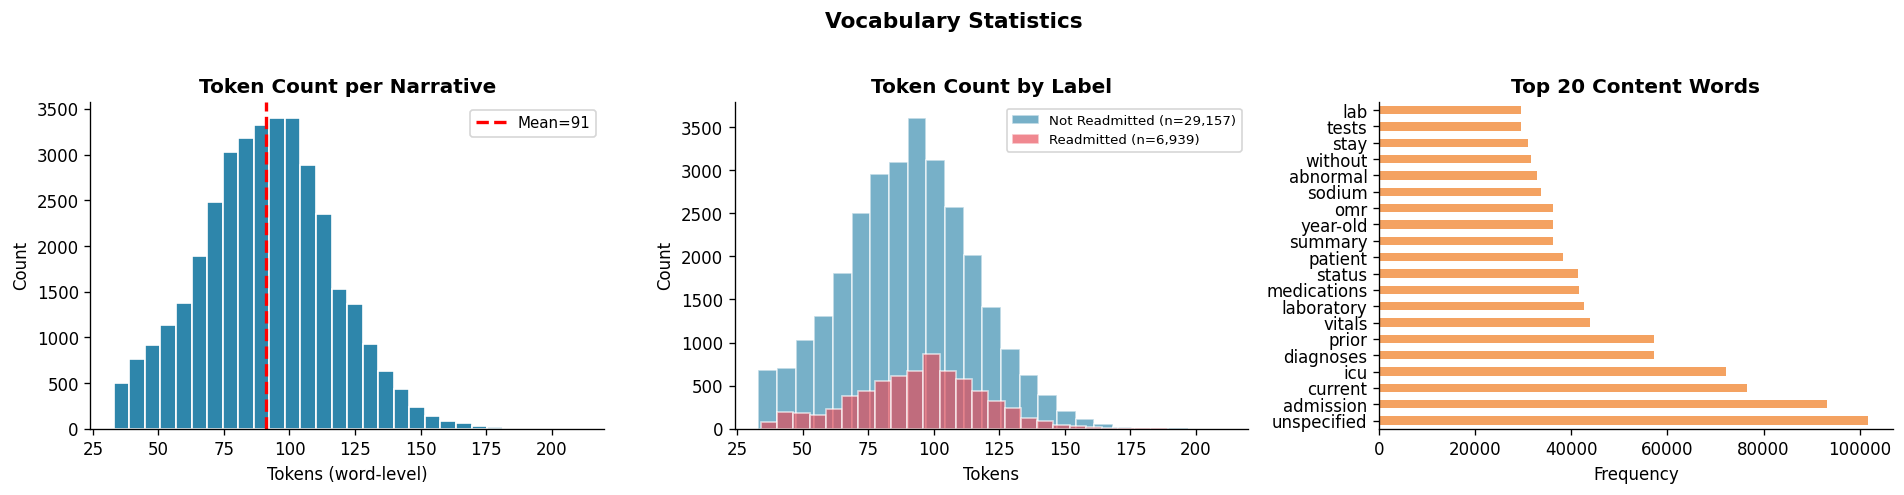

In [4]:
# Plot Setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Token Count Distribution
axes[0].hist(
    dataset['token_count'],
    bins=30,
    color=PALETTE[0],
    edgecolor='white'
)

axes[0].axvline(
    dataset['token_count'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Mean={dataset["token_count"].mean():.0f}'
)

axes[0].set_title('Token Count per Narrative', fontweight='bold')
axes[0].set_xlabel('Tokens (word-level)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)


# Token Count by Label
for label, color in [(0, PALETTE[0]), (1, PALETTE[1])]:
    sub = dataset[dataset['readmission_30d'] == label]['token_count']

    axes[1].hist(
        sub,
        bins=25,
        alpha=0.65,
        color=color,
        edgecolor='white',
        label=f'{"Readmitted" if label else "Not Readmitted"} (n={len(sub):,})'
    )

axes[1].set_title('Token Count by Label', fontweight='bold')
axes[1].set_xlabel('Tokens')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

# Top Content Words
top20 = pd.Series(dict(vocab_content.most_common(20)))

top20.sort_values()[::-1].plot(
    kind='barh',
    ax=axes[2],
    color=PALETTE[2]
)

axes[2].set_title('Top 20 Content Words', fontweight='bold')
axes[2].set_xlabel('Frequency')


# Save and Display
plt.suptitle(
    'Vocabulary Statistics',
    fontsize=13,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_01_vocabulary_stats.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Zipf's Law Analysis of the Clinical Vocabulary

This section examines the distribution of word frequencies within the clinical narrative corpus using Zipf’s Law. Zipf’s Law states that the frequency of a word is inversely proportional to its rank in the frequency table, a property commonly observed in natural language.

The first plot presents the frequency distribution of the top-ranked terms on a linear scale, highlighting the dominance of a small number of highly frequent words. This provides insight into the most commonly occurring terms within the corpus and their relative importance.

The second plot visualises the full vocabulary on a log-log scale, where a linear trend indicates adherence to Zipfian behaviour. This representation allows for clearer observation of the long-tail distribution, where many terms occur infrequently but collectively contribute to the richness of the vocabulary.

Together, these visualisations confirm the expected statistical properties of natural language within the dataset and provide useful context for feature engineering decisions, such as vocabulary truncation and weighting schemes.

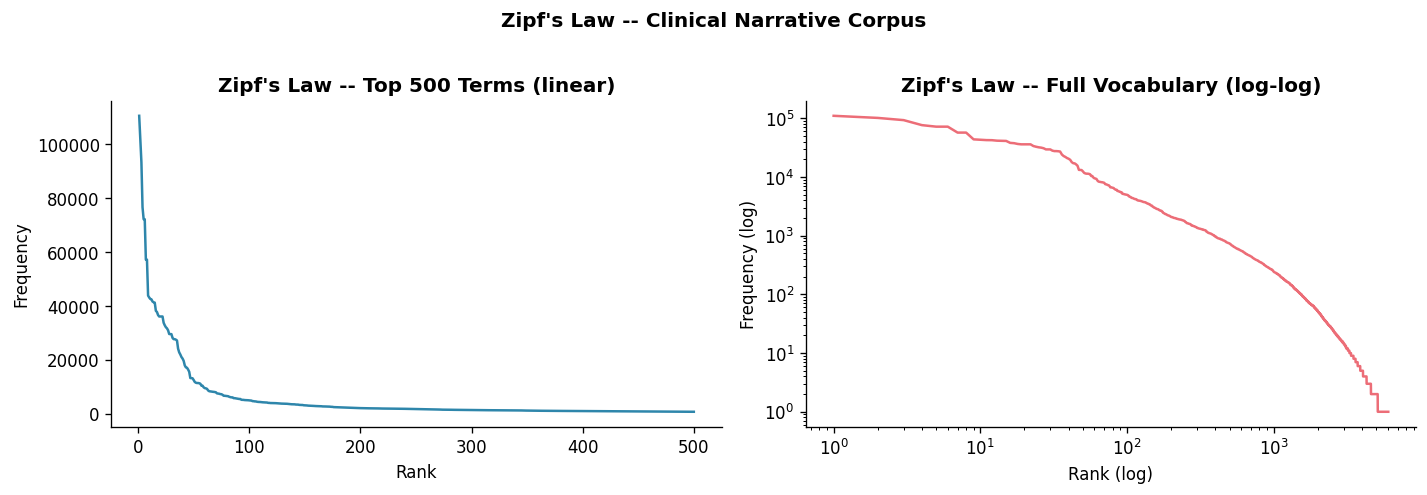

In [5]:
# Frequency and Rank
freqs = sorted(vocab_all.values(), reverse=True)
ranks = np.arange(1, len(freqs) + 1)


# Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Linear Scale (Top Terms)
axes[0].plot(
    ranks[:500],
    freqs[:500],
    color=PALETTE[0],
    lw=1.5
)

axes[0].set_title("Zipf's Law -- Top 500 Terms (linear)", fontweight='bold')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')

# Log-Log Scale (Full Vocabulary)
axes[1].loglog(
    ranks,
    freqs,
    color=PALETTE[1],
    lw=1.5,
    alpha=0.8
)

axes[1].set_title("Zipf's Law -- Full Vocabulary (log-log)", fontweight='bold')
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frequency (log)')

# Save and Display
plt.suptitle(
    "Zipf's Law -- Clinical Narrative Corpus",
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_02_zipf_law.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Subword Tokenisation Analysis Across Transformer Models

This section evaluates the behaviour of different transformer tokenisers on clinical text, with a focus on subword tokenisation efficiency and sequence length characteristics. Understanding how tokenisers segment domain-specific terminology is essential for selecting an appropriate model and configuring input length constraints.

A set of clinically relevant terms is first analysed to compare how each tokeniser decomposes specialised medical phrases. Token counts for each term are computed across DistilBERT, PubMedBERT, and BioBERT, allowing identification of which model produces more compact representations. Efficient tokenisation is particularly important in clinical domains, where long and complex terminology is common.

To extend this analysis, a sample of narratives is used to compute subword token lengths at the document level. Summary statistics, including mean length, standard deviation, and coverage under common maximum sequence thresholds, are reported. These metrics provide insight into how well each model accommodates the dataset within typical input limits.

Finally, token length distributions are visualised to highlight variability across models and to assess the proportion of narratives exceeding predefined thresholds. This analysis supports informed decisions regarding model selection and maximum sequence length configuration for downstream transformer-based modelling.

In [6]:
# Tokeniser Loading
tok_db = AutoTokenizer.from_pretrained(DISTILBERT_MODEL_ID)
tok_pm = AutoTokenizer.from_pretrained(PUBMEDBERT_MODEL_ID)
tok_bb = AutoTokenizer.from_pretrained(BIOBERT_MODEL_ID)


# Clinical Terms (including OMR terms)
clinical_terms = [
    'myocardial infarction',
    'percutaneous coronary intervention',
    'metoprolol tartrate',
    'hypertensive heart disease',
    'body mass index',
    'estimated glomerular filtration rate',
    'electrocardiogram',
    'hyperlipidaemia',
]


# Token Length Comparison
print(f'\n{"Term":<42}  {"DistilBERT":>12}  {"PubMedBERT":>12}  {"BioBERT":>10}')
print('-' * 84)

for term in clinical_terms:
    n_db = len(tok_db.tokenize(term))
    n_pm = len(tok_pm.tokenize(term))
    n_bb = len(tok_bb.tokenize(term))
    best = min(n_db, n_pm, n_bb)
    print(f'{term:<42}  {n_db:>12}  {n_pm:>12}  {n_bb:>10}{flag}')

# Sample Narratives 
sample_texts = dataset['narrative'].sample(
    min(5000, len(dataset)),
    random_state=42
).tolist()

print(f'Computing subword lengths on {len(sample_texts):,} sampled narratives...')

# Token Length Computation
len_db = [len(tok_db.tokenize(t)) for t in sample_texts]
len_pm = [len(tok_pm.tokenize(t)) for t in sample_texts]
len_bb = [len(tok_bb.tokenize(t)) for t in sample_texts]

# Summary Statistics
print(f'\n{"Tokeniser":<15} {"Mean":>7} {"Std":>6} {"<=128":>7} {"<=256":>7} {"<=512":>7}')
print('-' * 55)

for name, lens in [
    ('DistilBERT', len_db),
    ('PubMedBERT', len_pm),
    ('BioBERT',    len_bb)
]:
    a = np.array(lens)

    print(
        f'{name:<15} {a.mean():>7.1f} {a.std():>6.1f} '
        f'{(a<=128).mean()*100:>6.1f}% '
        f'{(a<=256).mean()*100:>6.1f}% '
        f'{(a<=512).mean()*100:>6.1f}%'
    )

# Plot Setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Token Length Distributions
for ax, (name, lens, color) in zip(axes, [
    ('DistilBERT', len_db, PALETTE[0]),
    ('PubMedBERT', len_pm, PALETTE[1]),
    ('BioBERT',    len_bb, PALETTE[2])
]):
    ax.hist(
        lens,
        bins=25,
        color=color,
        edgecolor='white'
    )

    ax.axvline(256, color='red', linestyle='--', lw=2, label='max_length=256')

    ax.axvline(
        np.mean(lens),
        color='orange',
        linestyle='-.',
        lw=1.5,
        label=f'Mean={np.mean(lens):.0f}'
    )

    ax.set_title(f'{name} Token Lengths', fontweight='bold')
    ax.set_xlabel('Subword tokens')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)


# Save and Display
plt.suptitle(
    'Subword Token Length Distributions',
    fontsize=12,
    fontweight='bold',
    y=1.03
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_03_bert_token_lengths.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


Term                                          DistilBERT    PubMedBERT     BioBERT
------------------------------------------------------------------------------------


NameError: name 'flag' is not defined

## TF-IDF Feature Analysis and Class-Discriminative Terms

This section examines class-discriminative textual features using Term Frequency–Inverse Document Frequency (TF-IDF) representations. TF-IDF is widely used in natural language processing to capture the importance of terms within documents while down-weighting commonly occurring words.

A subset of narratives is sampled to ensure computational efficiency while maintaining representative coverage of the dataset. The text is then transformed into a TF-IDF feature matrix using both unigrams and bigrams, enabling the model to capture individual terms as well as short contextual phrases.

To identify discriminative features, the mean TF-IDF values are computed separately for readmitted and non-readmitted patients. The difference between these class-wise means highlights terms that are more strongly associated with each class. Positive differences indicate features more prevalent in readmitted cases, while negative differences correspond to features more characteristic of non-readmitted cases.

The most discriminative features for each class are visualised to provide insight into the linguistic patterns that distinguish patient outcomes. This analysis supports feature interpretability and offers an intuitive understanding of the signals captured by the model.

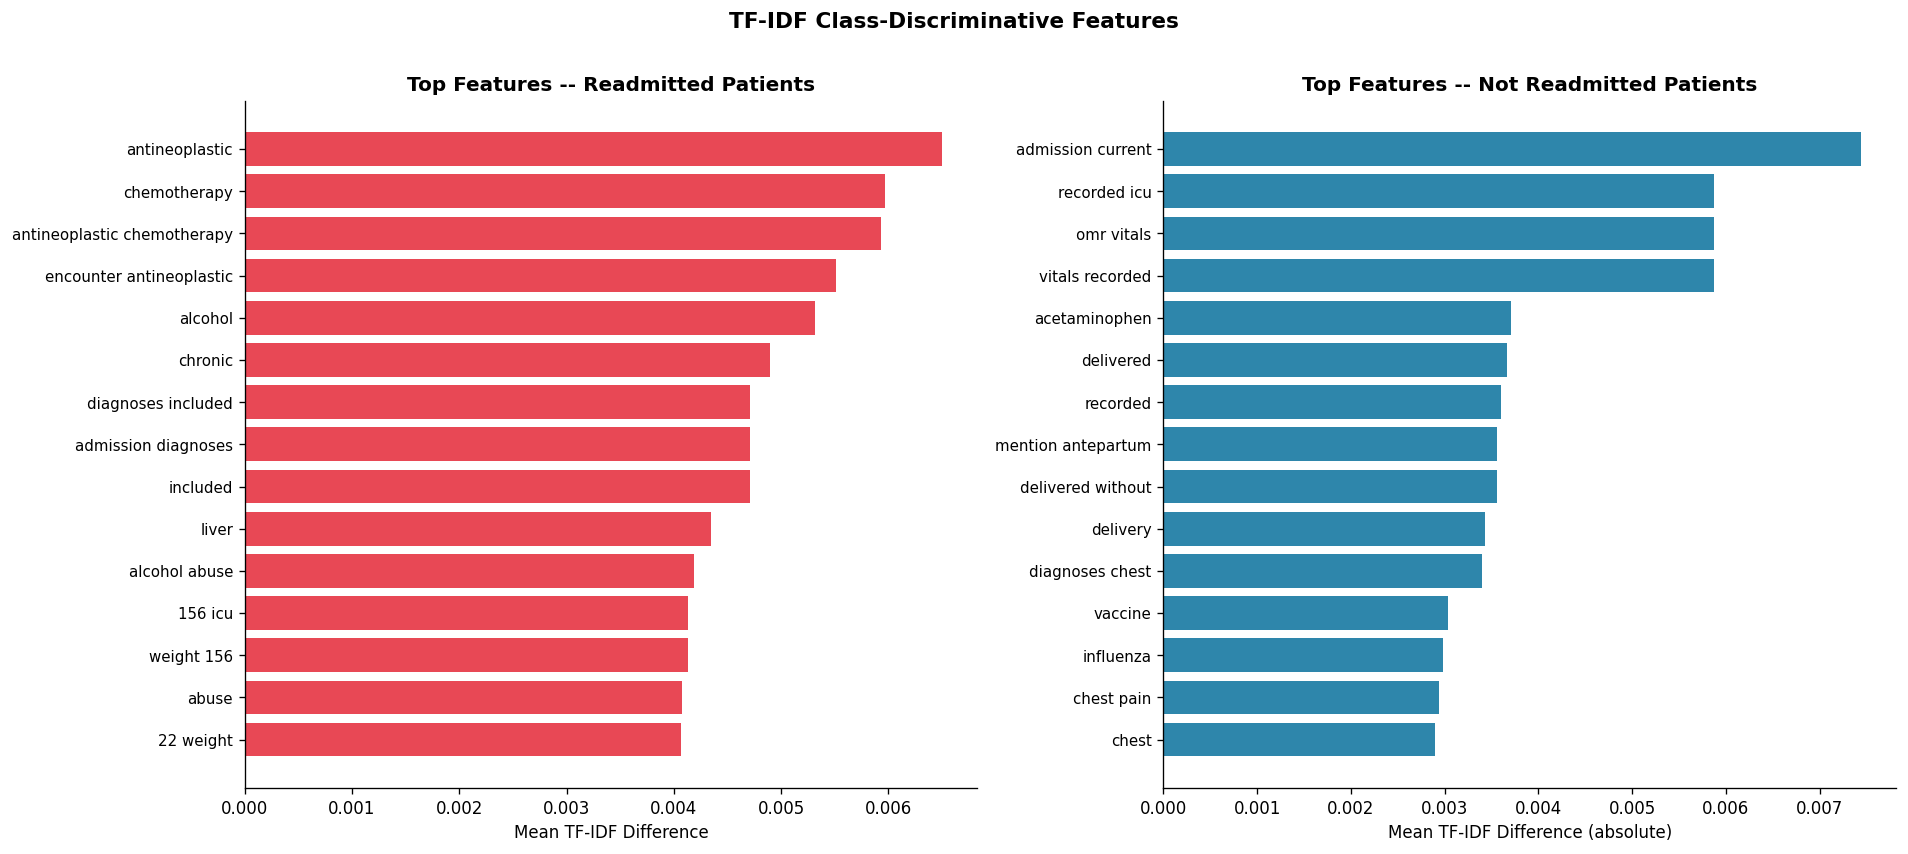

In [ ]:
# Sample Texts for TF-IDF
sample_idx = np.random.RandomState(42).choice(
    len(all_texts),
    size=min(50000, len(all_texts)),
    replace=False
)

sample_texts_tfidf = [all_texts[i] for i in sample_idx]
sample_y = y[sample_idx]

# TF-IDF Vectorisation
tfidf_vec = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    stop_words=list(STOP),
    sublinear_tf=True,
    min_df=3
)

X_tfidf = tfidf_vec.fit_transform(sample_texts_tfidf)
feat_names = np.array(tfidf_vec.get_feature_names_out())

# Class-Wise Mean TF-IDF
mean_pos = X_tfidf[sample_y == 1].mean(axis=0).A1
mean_neg = X_tfidf[sample_y == 0].mean(axis=0).A1

diff = mean_pos - mean_neg

# Top Disciminative Features
top_pos = diff.argsort()[-18:][::-1]
top_neg = diff.argsort()[:18]


# Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Readmitted Features
axes[0].barh(
    range(15),
    diff[top_pos[:15]][::-1],
    color=PALETTE[1]
)

axes[0].set_yticks(range(15))
axes[0].set_yticklabels(feat_names[top_pos[:15]][::-1], fontsize=9)
axes[0].set_title('Top Features -- Readmitted Patients', fontweight='bold')
axes[0].set_xlabel('Mean TF-IDF Difference')

# Not Readmitted Features
axes[1].barh(
    range(15),
    abs(diff[top_neg[:15]][::-1]),
    color=PALETTE[0]
)

axes[1].set_yticks(range(15))
axes[1].set_yticklabels(feat_names[top_neg[:15]][::-1], fontsize=9)
axes[1].set_title('Top Features -- Not Readmitted Patients', fontweight='bold')
axes[1].set_xlabel('Mean TF-IDF Difference (absolute)')

# Save and Display
plt.suptitle(
    'TF-IDF Class-Discriminative Features',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_04_tfidf_class_features.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## N-Gram Analysis for Class-Specific Patterns

This section explores class-specific linguistic patterns using n-gram analysis, focusing on bigrams to capture short contextual phrases within the clinical narratives. While unigrams provide information about individual word usage, bigrams offer additional insight into local word relationships and commonly co-occurring terms.

A subset of narratives is used to compute n-gram frequencies efficiently while maintaining representative coverage of the dataset. Separate analyses are performed for readmitted and non-readmitted patients, allowing comparison of phrase-level patterns across outcome groups.

The most frequent bigrams for each class are identified and visualised to highlight dominant expressions within the narratives. These phrases often correspond to recurring clinical descriptions, treatment patterns, or diagnostic contexts, and can provide valuable interpretability for model behaviour.

Overall, this analysis complements earlier TF-IDF results by capturing contextual information at the phrase level, offering a more nuanced understanding of linguistic differences between patient groups.

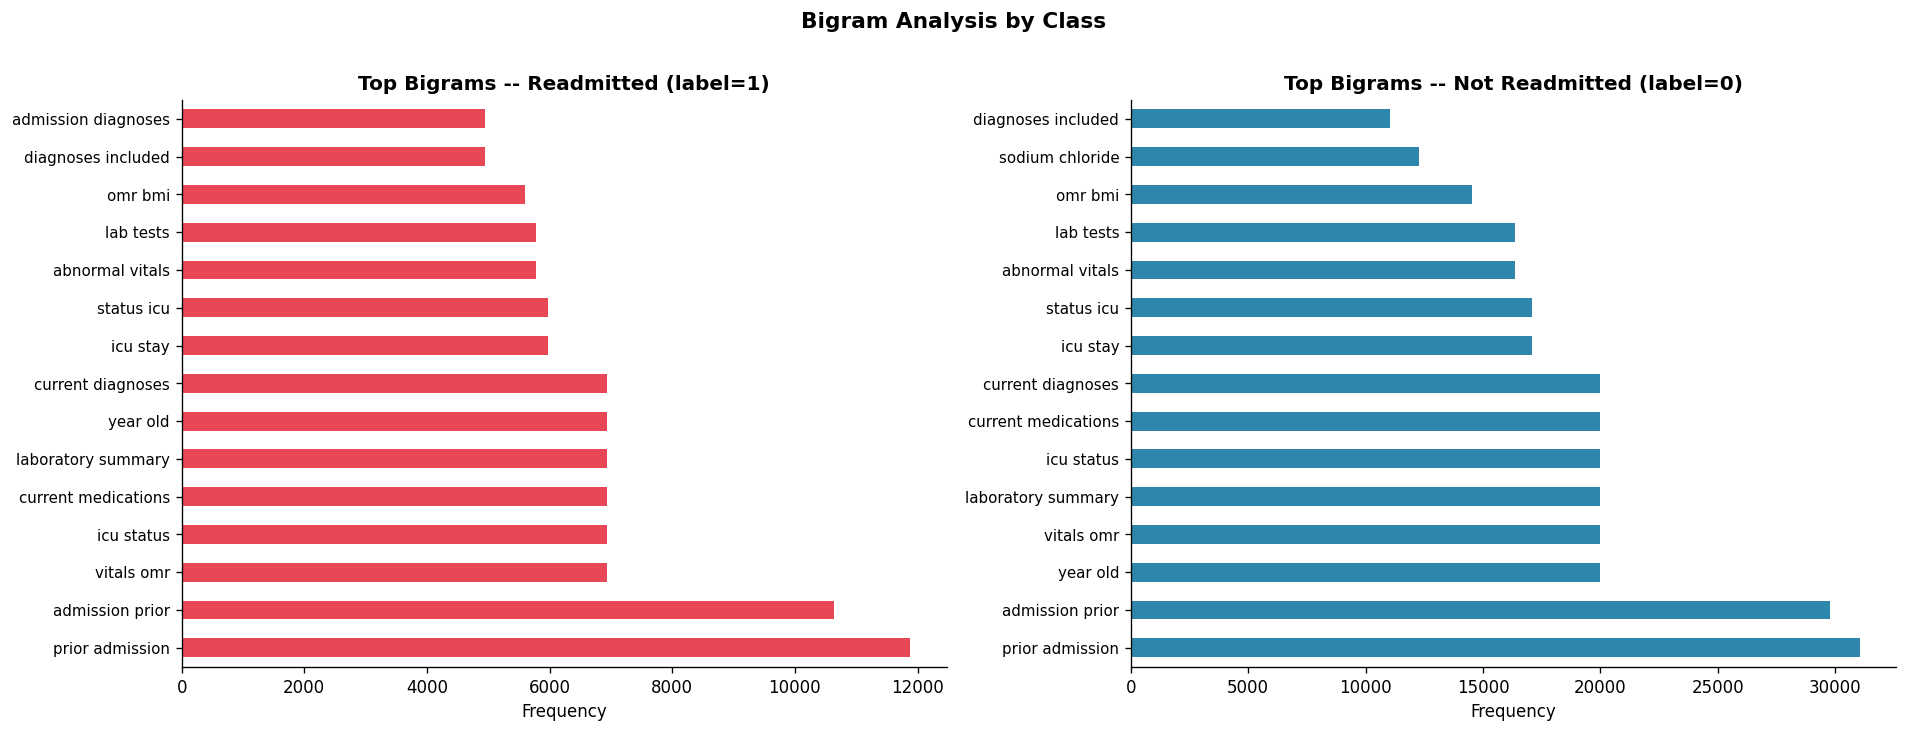

In [ ]:
# Function to get Top N-Grams
def top_ngrams(texts, n, k=15):
    sample = texts[:min(20000, len(texts))]

    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words=list(STOP),
        max_features=5000
    )

    X = vec.fit_transform(sample)

    return pd.Series(
        X.sum(axis=0).A1,
        index=vec.get_feature_names_out()
    ).sort_values(ascending=False).head(k)

# Compute Bigrams by Class
bi_pos = top_ngrams(pos_texts, n=2)
bi_neg = top_ngrams(neg_texts, n=2)

# Plot Setup
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Readmitted Bigrams
bi_pos.sort_values()[::-1].plot(
    kind='barh',
    ax=axes[0],
    color=PALETTE[1]
)

axes[0].set_title('Top Bigrams -- Readmitted (label=1)', fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].tick_params(axis='y', labelsize=9)

# Not Readmitted Bigrams
bi_neg.sort_values()[::-1].plot(
    kind='barh',
    ax=axes[1],
    color=PALETTE[0]
)

axes[1].set_title('Top Bigrams -- Not Readmitted (label=0)', fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].tick_params(axis='y', labelsize=9)

# Save and Display
plt.suptitle(
    'Bigram Analysis by Class',
    fontsize=13,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()

plt.savefig(
    f'{FEATURE_ANALYSIS_PLT}/feat_05_ngram_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## Corpus Statistics Summary

This section provides an overview of the dataset and extracted textual features, offering a consolidated view of corpus characteristics relevant to downstream modelling.

Key statistics include dataset size, vocabulary richness, token-level properties, and class distribution. The Type–Token Ratio (TTR) is used to quantify lexical diversity, while average token counts capture narrative length variability.

Subword token statistics are also reported for multiple transformer tokenisers (DistilBERT, PubMedBERT, and BioBERT), providing insight into how efficiently each model represents the clinical narratives. This is particularly important for determining appropriate sequence lengths and understanding tokenisation behaviour in biomedical contexts.

Finally, dataset metadata such as the number of unique patients and the inclusion of structured clinical signals (e.g., OMR-derived vitals) are summarised to contextualise the feature space used in modelling.

In [ ]:
# Corpus Statistics Summary
print('=' * 64)
print('  CORPUS STATISTICS  ')
print('=' * 64)

# Dataset Size and Vocabulary
print(f'  Total narratives : {len(dataset):,}')
print(f'  Vocabulary (all tokens) : {len(vocab_all):,}')
print(f'  Vocabulary (content tokens) : {len(vocab_content):,}')
print(f'  Type-Token Ratio (TTR) : {len(vocab_all)/len(all_tokens):.4f}')

# Token Statistics
print(
    f'  Avg word tokens / narrative : {dataset["token_count"].mean():.1f} '
    f'+/- {dataset["token_count"].std():.1f}'
)

# Subword Token Statistics
print(f'  Avg DistilBERT tokens : {np.mean(len_db):.1f} +/- {np.std(len_db):.1f}')
print(f'  Avg PubMedBERT tokens : {np.mean(len_pm):.1f} +/- {np.std(len_pm):.1f}')
print(f'  Avg BioBERT tokens : {np.mean(len_bb):.1f} +/- {np.std(len_bb):.1f}')

# Class Distribution
print(
    f'  Positive class (readmitted) : {dataset["readmission_30d"].sum():,} '
    f'({dataset["readmission_30d"].mean()*100:.1f}%)'
)

# Dataset Metadata
print(f'  Unique patients : {dataset["subject_id"].nunique():,}')
print(f'  OMR vitals in narratives : YES (BMI, weight from omr table)')
print(f'  dod correction applied : YES')

print('=' * 64)

  CORPUS STATISTICS  
  Total narratives : 36,096
  Vocabulary (all tokens) : 6,043
  Vocabulary (content tokens) : 5,982
  Type-Token Ratio (TTR) : 0.0018
  Avg word tokens / narrative : 91.2 +/- 25.0
  Avg DistilBERT tokens : 198.5 +/- 50.3
  Avg PubMedBERT tokens : 165.2 +/- 38.8
  Avg BioBERT tokens : 218.4 +/- 55.5
  Positive class (readmitted) : 6,939 (19.2%)
  Unique patients : 15,003
  OMR vitals in narratives : YES (BMI, weight from omr table)
  dod correction applied : YES
